assymetry initial  0.019468998903470355
assymetry final  0.008998915846838373
0.9954734375311877 -0.2068714856960839 0.2068714856960839


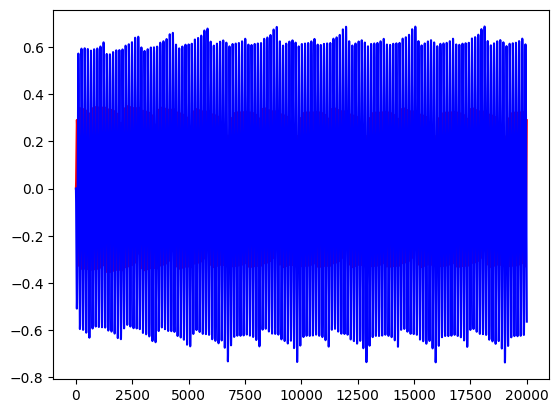

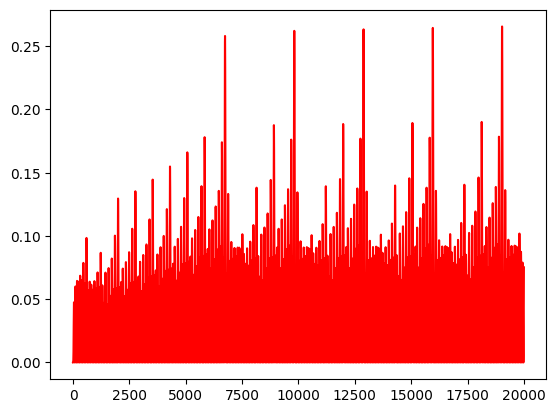

In [4]:
import numpy
import matplotlib.pyplot as plt


def sgn(x):
    if x > 0:
        return 1
    elif x < 0:
        return -1
    else:
        return 0


def smooth_friction(x):
    return x/(1 + abs(x))

def smooth_friction_der(x):
    return 1/((1 + abs(x))**2)

class Motor:
    def __init__(self, k_motor, tau_motor, torque_th, kb, dt):
        # continuous model
        a_con = -1.0/tau_motor    
        b_con = k_motor*(1.0/tau_motor)

        # discrete model
        self.a = (1 + a_con*dt*0.5)/(1 - a_con*dt*0.5)
        self.b = (b_con*dt)/(1 - a_con*dt*0.5)

        self.torque_th = torque_th
        self.kb        = kb

        self.dt        = dt

        self.velocity = 0.0
        self.position = 0.0

    def step(self, u):
        u_tmp = float(u)

        # clamping, friction force
        if abs(u_tmp) < self.torque_th:
            u_tmp = 0.0

        # scaling torque
        u_tmp = u_tmp + self.kb

        # motor velocity
        self.velocity = self.a*self.velocity + self.b*u_tmp

        # position change simulation
        self.position+= self.velocity*self.dt

        return self.position

    def get_position(self):
        return float(self.position)
    
    def get_velocity(self):
        return float(self.velocity)

dt = 1.0/2000.0


# create example motors
right_motor = Motor(200, 0.001*15, 0*0.07,  0, dt)
left_motor  = Motor(350, 0.001*15, 0*0.13,  0, dt)


torque_max = 0.2

# angle range
angle_max  = 30*numpy.pi/180.0

# simulation steps
n_steps = 20000

state = 0



# params to optimise
#Kfr = 1.0
#Kfl = 1.0

Kv = 0.0

Ktr = 0.0
Ktl = 0.0

Kcr = 0.0
Kcl = 0.0

# learning rate step
lr = 0.1


# logs
right_result = []
left_result  = []

batch_size = 128
asymmetry_batch = [] 
torque_right_batch = []
torque_left_batch = []

for n in range(n_steps):

    # current state
    right_position = right_motor.get_position()
    left_position  = left_motor.get_position()

    angle = right_position - left_position

    # set moving direction
    if state == 0:
        torque = torque_max
        if angle > angle_max:
            state = 1

    elif state == 1:
        torque = -torque_max
        if angle < -angle_max:
            state = 0

    # torque
    torque_right = torque
    torque_left  = -torque

    # torque compensation
    # motor constant asymmetry, friction force, motor model imperfection
    #u_right = Kfr*torque_right + Ktr*sgn(torque_right) #+ Kcr*right_model_error
    #u_left  = Kfl*torque_left  + Ktl*sgn(torque_left)  #+ Kcl*left_model_error

    u_right = (1.0 + Kv)*torque_right + Ktr*sgn(torque_right) #+ Kcr*right_model_error
    u_left  = (1.0 - Kv)*torque_left  + Ktl*sgn(torque_left)  #+ Kcl*left_model_error


    # loss function derivative
    asymmetry = right_position + left_position

    asymmetry_batch.append(asymmetry)
    torque_right_batch.append(torque_right)
    torque_left_batch.append(torque_left)
    

    if len(asymmetry_batch) >= batch_size:
        asymmetry_batch = numpy.array(asymmetry_batch)
        torque_right_batch = numpy.array(torque_right_batch)
        torque_left_batch = numpy.array(torque_left_batch)


        diff = (asymmetry_batch*(torque_right_batch - torque_left_batch)).mean()
        Kv = Kv + lr*diff


        diff = (asymmetry_batch*numpy.sign(torque_right)).mean()
        Ktr = Ktr + lr*diff

        diff = (asymmetry_batch*numpy.sign(torque_left)).mean()
        Ktl = Ktl + lr*diff


        asymmetry_batch = []
        torque_right_batch = []
        torque_left_batch = []


    eps = 10**-6

 
    # log results
    right_motor.step(u_right)
    left_motor.step(u_left)


    right_result.append(right_position)
    left_result.append(left_position)


# plotting and printing
right_result = numpy.array(right_result)
left_result  = numpy.array(left_result)

asymmetry    = ((right_result + left_result)**2)

n_test = 100 #n_steps//20
print("assymetry initial ", asymmetry[0:n_test].mean())
print("assymetry final ", asymmetry[-n_test].mean())

# print params
print(Kv, Ktr, Ktl)

plt.clf()
plt.plot(right_result, label="right_motor", color="red")
plt.plot(left_result, label="left_motor", color="blue")
plt.show()


plt.clf()
plt.plot(asymmetry, label="asymmetry", color="red")
plt.show()
